# ZINC Non-Streaming Demo

This notebook mirrors the lean streaming demo, but uses the regular in-memory `fit(...)` path.

- source: raw ZINC CSV
- sample limit: `0.1`
- fit mode: materialize sampled graphs, then train normally
- outputs: 7 samples without feasibility filtering, then 7 with filtering


In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

from pathlib import Path
import random
import warnings

import numpy as np
from IPython.core.display import HTML

HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell; text-align: center; vertical-align: middle;}</style>')

warnings.filterwarnings('ignore', message=r".*`isinstance\(treespec, LeafSpec\)` is deprecated.*")

from conditional_node_field_graph_generator.notebooks import configure_notebook, download_zinc_dataset
globals().update(configure_notebook(require_nsppk=True, print_torch=True))
import torch
torch.set_float32_matmul_precision('high')

from abstractgraph_graphicalizer.chem import draw_molecule, draw_molecules
from conditional_node_field_graph_generator.input_sources import iter_selected_source_graphs
from conditional_node_field_graph_generator.extensions.demo import show_molecules
from conditional_node_field_graph_generator.extensions.demo.visualization import plot_networkx_graphs
from conditional_node_field_graph_generator.extensions.demo.pipeline import build_graph_generator


PyTorch version: 2.11.0+cu128
CUDA available: True


In [2]:
ZINC_DATA_ROOT = NOTEBOOK_DATA_ROOT / 'zinc'
ZINC_SIZE = 'zinc20'
ZINC_FILENAME = f'{ZINC_SIZE}.csv'
RANDOM_SEED = 42
DATA_LIMIT = 55000
FIT_BATCH_SIZE = 256
MAXIMUM_EPOCHS = 350
LOSS_CURVES_PDF_EVERY_N_EPOCHS = 10

# Fit SVD bases on a fixed row sample, then project the full dataset.
EMBEDDING_DIM = 192
EMBEDDING_SVD_DIM = 64
EMBEDDING_SVD_FIT_MAX_ROWS = 10_000
EMBEDDING_SVD_TRANSFORM_BATCH_SIZE = 10_000
LEARNING_RATE = 1e-4
SPARSE_SUPERVISION_MASK_RATIO = 0.35

# Capacity knobs. If this still underfits, the next escalation is d=256 with
# the same batch/LR before increasing depth again.
NUMBER_OF_TRANSFORMER_LAYERS = 4
TRANSFORMER_ATTENTION_HEAD_COUNT = 8
TRANSFORMER_DROPOUT = 0.15

# Structural supervision weights.
LAMBDA_DEGREE_IMPORTANCE = 4.0
LAMBDA_NODE_LABEL_IMPORTANCE = 3.0
LAMBDA_EDGE_LABEL_IMPORTANCE = 3.0
LAMBDA_DIRECT_EDGE_IMPORTANCE = 3.0
LAMBDA_AUXILIARY_EDGE_IMPORTANCE = 2.0

MODEL_NAME = (
    f'{ZINC_SIZE}-nonstreaming-d{EMBEDDING_DIM}-svd{EMBEDDING_SVD_DIM}-s{DATA_LIMIT}'
    f'-b{FIT_BATCH_SIZE}-lr{LEARNING_RATE:g}-mask{SPARSE_SUPERVISION_MASK_RATIO:g}'
    f'-l{NUMBER_OF_TRANSFORMER_LAYERS}-drop{TRANSFORMER_DROPOUT:g}'
    f'-e{MAXIMUM_EPOCHS}'
)
# Keep preprocessing serial for the non-streaming notebook. The parallel
# vectorizer/feasibility path can wedge in long-lived notebook kernels before
# training starts, leaving no useful progress output.
VECTORIZER_PARALLEL = True
FEASIBILITY_PARALLEL = True
FEASIBILITY_N_JOBS = -1
DECODER_N_JOBS = -1
DECODER_SOLVER_THREADS = 16

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


In [3]:
csv_path = download_zinc_dataset(ZINC_DATA_ROOT, filename=ZINC_FILENAME)
print(f'ZINC CSV: {csv_path}')

graphs = list(
    iter_selected_source_graphs(
        csv_path,
        'zinc_csv',
        limit=DATA_LIMIT,
        random_state=RANDOM_SEED,
    )
)
print(f'Loaded {len(graphs)} graphs into memory for non-streaming fit.')

graph_generator = build_graph_generator(
    latent_embedding_dimension=EMBEDDING_DIM,
    node_embedding_svd_dimension=EMBEDDING_SVD_DIM,
    graph_embedding_svd_dimension=EMBEDDING_SVD_DIM,
    embedding_svd_fit_max_rows=EMBEDDING_SVD_FIT_MAX_ROWS,
    embedding_svd_transform_batch_size=EMBEDDING_SVD_TRANSFORM_BATCH_SIZE,
    number_of_transformer_layers=NUMBER_OF_TRANSFORMER_LAYERS,
    transformer_attention_head_count=TRANSFORMER_ATTENTION_HEAD_COUNT,
    transformer_dropout=TRANSFORMER_DROPOUT,
    node_vectorizer_dense=False,
    graph_vectorizer_dense=False,
    node_vectorizer_parallel=VECTORIZER_PARALLEL,
    graph_vectorizer_parallel=VECTORIZER_PARALLEL,
    feasibility_parallel=FEASIBILITY_PARALLEL,
    feasibility_n_jobs=FEASIBILITY_N_JOBS,
    locality_horizon=2,
    sparse_supervision_mask_ratio=SPARSE_SUPERVISION_MASK_RATIO,
    learning_rate=LEARNING_RATE,
    lambda_degree_importance=LAMBDA_DEGREE_IMPORTANCE,
    lambda_node_label_importance=LAMBDA_NODE_LABEL_IMPORTANCE,
    lambda_edge_label_importance=LAMBDA_EDGE_LABEL_IMPORTANCE,
    lambda_direct_edge_importance=LAMBDA_DIRECT_EDGE_IMPORTANCE,
    lambda_auxiliary_edge_importance=LAMBDA_AUXILIARY_EDGE_IMPORTANCE,
    maximum_epochs=MAXIMUM_EPOCHS,
    batch_size=FIT_BATCH_SIZE,
    verbose=1,
    decoder_n_jobs=DECODER_N_JOBS,
    decoder_solver_threads=DECODER_SOLVER_THREADS,
    artifact_root=ARTIFACT_ROOT,
    checkpoint_root=CHECKPOINT_ROOT,
    model_name=MODEL_NAME,
    model_dir=SAVED_GENERATOR_ROOT,
)
print('node_vectorizer_dense =', graph_generator.node_graph_vectorizer.dense)
print('graph_vectorizer_dense =', graph_generator.graph_vectorizer.dense)
graph_generator.loss_curves_pdf_every_n_epochs = LOSS_CURVES_PDF_EVERY_N_EPOCHS
graph_generator.graph_decoder.diagnostic_graph_renderer = draw_molecules

TRAINING_PROGRESS_MOLECULE_PLOT_KWARGS = {
    'size': (500, 350),
    'cell_size': 2.8,
    'title_font_size': 8,
}
TRAINING_PROGRESS_PDF_PATH = ARTIFACT_ROOT / 'samples' / MODEL_NAME / 'training_samples.pdf'
print(f'Training sample PDF: {TRAINING_PROGRESS_PDF_PATH}')


ZINC CSV: /cs0eth/home/fc334/code/NodeField/notebooks/datasets/zinc/zinc20.csv
Loaded 55000 graphs into memory for non-streaming fit.
Configured graph generator model_name=zinc20-nonstreaming-d192-svd64-s55000-b256-lr0-0001-mask0-35-l4-drop0-15-e350 model_dir=/cs0eth/home/fc334/code/NodeField/.artifacts/saved_generators
node_vectorizer_dense = False
graph_vectorizer_dense = False
Training sample PDF: /cs0eth/home/fc334/code/NodeField/.artifacts/samples/zinc20-nonstreaming-d192-svd64-s55000-b256-lr0.0001-mask0.35-l4-drop0.15-e350/training_samples.pdf


Fit target model_name=zinc20-nonstreaming-d192-svd64-s55000-b256-lr0-0001-mask0-35-l4-drop0-15-e350 model_dir=/cs0eth/home/fc334/code/NodeField/.artifacts/saved_generators
Fitting model on 55000 graphs
Fitting graph vectorizer on 55000 graphs
Finished fitting graph vectorizer on 55000 graphs in 0m 0.0s
Fitting node graph vectorizer on 55000 graphs
Finished fitting node graph vectorizer on 55000 graphs in 0m 0.0s
Encoding node embeddings for 55000 graphs
Finished encoding node embeddings for 55000 graphs in 1m 37.2s
Encoding graph embeddings for 55000 graphs
Finished encoding graph embeddings for 55000 graphs in 1m 35.7s
Fitting embedding SVDs
Stacking raw node embeddings for SVD.
Stacked node embedding matrix: shape=(975153, 2048), sparse=True, nnz=164993605, density=0.082616.
Prepared graph embedding matrix: shape=(55000, 2048), sparse=True, nnz=50572099, density=0.448971.
Sampled node embedding SVD fit rows: 975153 -> 10000.
Fitting node embedding SVD on shape=(10000, 2048), sparse=T

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


epoch 1: completed epoch in 70.71s
epoch 2: completed epoch in 75.42s
epoch 3: completed epoch in 71.81s
epoch 4: completed epoch in 71.90s
epoch 5: completed epoch in 72.10s
epoch 6: completed epoch in 71.90s
epoch 7: completed epoch in 75.34s
epoch 8: completed epoch in 71.80s
epoch 9: completed epoch in 71.86s
Epoch 10/350 | ETA 6h 44m 16s:
  train total=   62.491 | node_field    21.534 [34.5%] |        deg    1.8518 [3.0%] |      exist   0.13527 [0.2%] | node_count   0.00264 [<0.1%]
  val   total=   60.753 | node_field    21.263 [35.0%] |        deg    1.7034 [2.8%] |      exist   0.13627 [0.2%] | node_count   0.00264 [<0.1%]
  train                 | node_label   0.59695 [1.0%] | edge_label   0.54873 [0.9%] |       edge    2.1898 [3.5%] | edge_count    34.186 [54.7%] | deg_edge_consistency   0.00015 [<0.1%]
  val                   | node_label   0.53073 [0.9%] | edge_label   0.48620 [0.8%] |       edge    2.0905 [3.4%] | edge_count    33.158 [54.6%] | deg_edge_consistency   0.0001

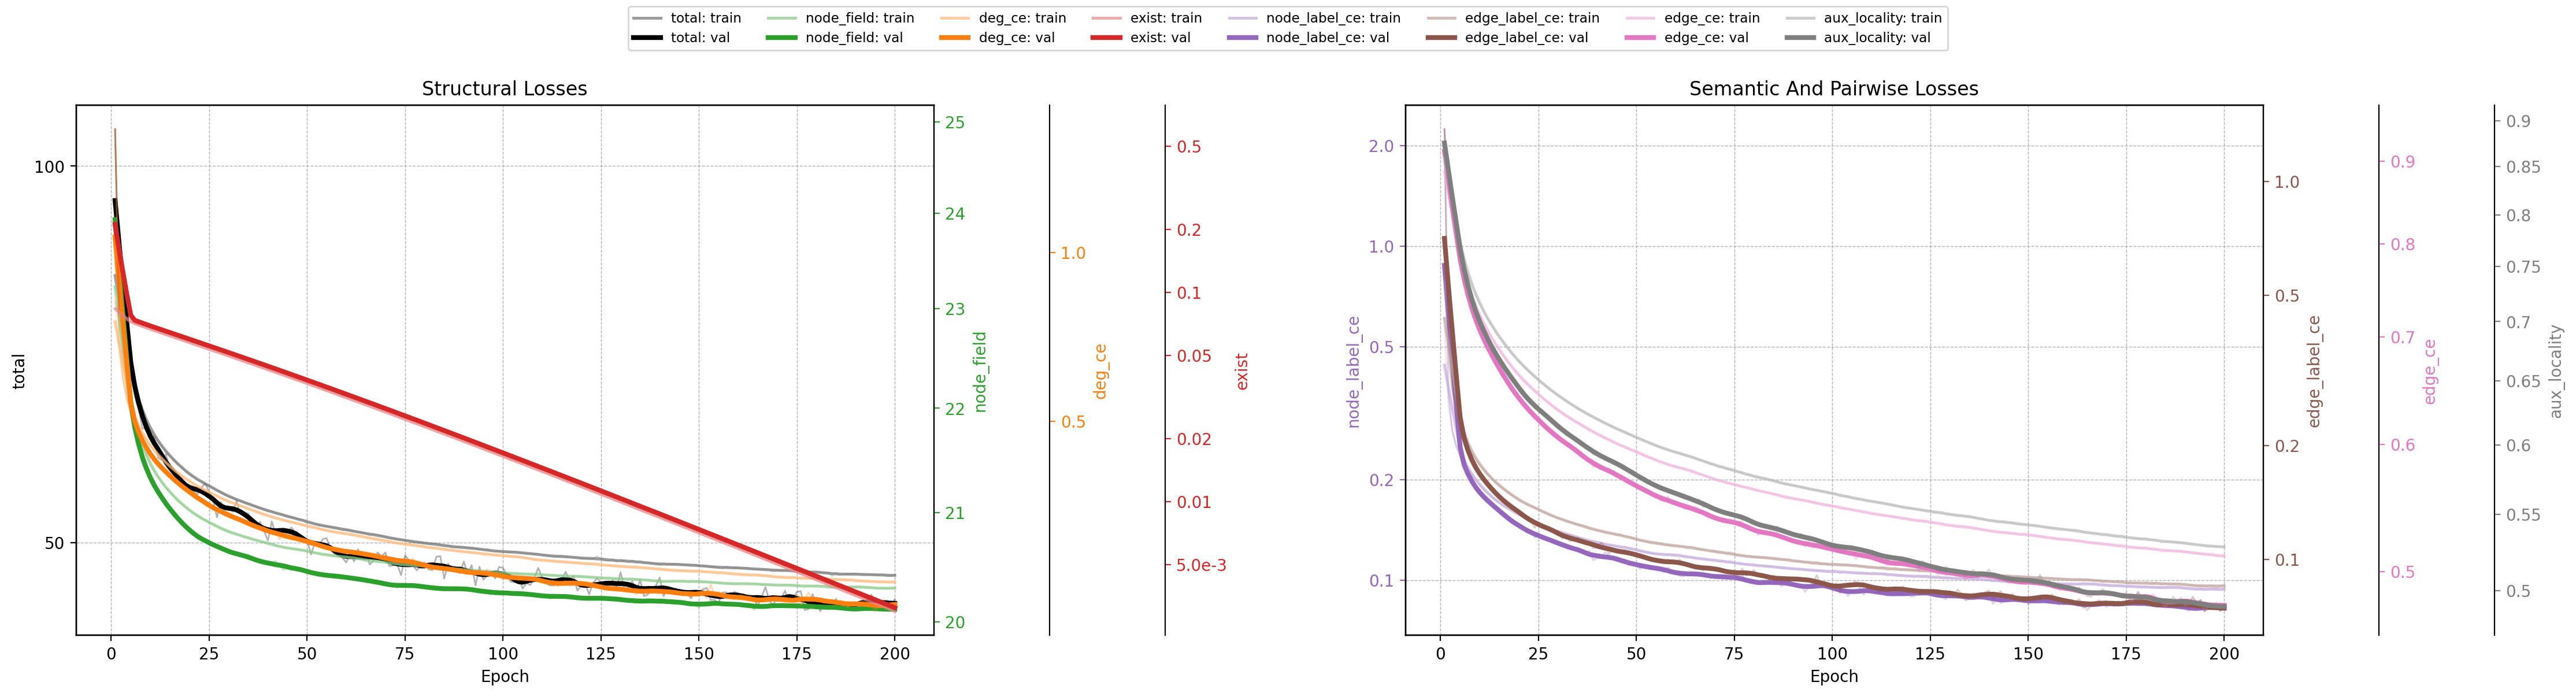

training_graph_conditioning_ = 55000
is_fitted_ = True


In [4]:
graph_generator.fit(
    graphs,
    train_node_generator=True,
    targets=None,
    sample_training_progress=True,
    sample_training_progress_n_samples=1,
    sample_training_progress_every_n_epochs=50,
    sample_training_progress_pdf_path=TRAINING_PROGRESS_PDF_PATH,
    sample_training_progress_plot_kwargs=TRAINING_PROGRESS_MOLECULE_PLOT_KWARGS,
    sample_training_progress_plot_fn=draw_molecule,
)

print('training_graph_conditioning_ =', len(graph_generator.training_graph_conditioning_))
print('is_fitted_ =', graph_generator.is_fitted_)


In [5]:
#load model
from conditional_node_field_graph_generator.persistence import (
    list_saved_graph_generators,
    load_graph_generator,
)
SAVED_GENERATOR_ROOT = REPO_ROOT / '.artifacts' / 'saved_generators'
list_saved_graph_generators(SAVED_GENERATOR_ROOT)
#MODEL_NAME = 'zinc15-nonstreaming-d64-s10000-b128-e350'
graph_generator = load_graph_generator(MODEL_NAME+'.pkl', model_dir=SAVED_GENERATOR_ROOT)
graph_generator.graph_decoder.solver_threads = DECODER_SOLVER_THREADS


,name,modified,size_mb
0,zinc20-nonstreaming-d192-svd64-s55000-b256-lr0-0001-mask0-35-l4-drop0-15-e350.pkl,2026-06-10 21:04,45.100000
1,artificial-cycle-path-star-n9000-c4-p-2-6-r2x1-d128-b128-e350.pkl,2026-06-10 14:54,20.300000
2,zinc20-nonstreaming-d192-s33000-b256-lr0-0001-mask0-35-l4-drop0-15-e350.pkl,2026-06-09 23:16,70.500000
3,zinc20-nonstreaming-d192-s5000-b256-lr0-0001-mask0-35-l4-drop0-15-e350.pkl,2026-06-09 14:53,29.000000
4,zinc20-nonstreaming-d192-s1000-b256-lr0-0001-mask0-35-l4-drop0-15-e350.pkl,2026-06-09 11:22,23.100000
5,artificial-cycle-path-star-n60000-c4-nc2-p2-r2x2-d128-b128-e350.pkl,2026-06-08 13:50,70.900000
6,zinc20-nonstreaming-d128-s50000-b512-lr0-0002-mask0-5-e350.pkl,2026-06-05 20:06,61.000000
7,artificial-cycle-path-star-n6000-c4-nc2-p2-r2x2-d64-b128-e350.pkl,2026-06-05 20:01,8.900000
8,artificial-cycle-path-star-n6000-c4-p2-r2x2-d64-b128-e350.pkl,2026-06-05 17:40,8.900000
9,artificial-cycle-path-star-n2500-c4-p2-r2x2-d64-b128-e350.pkl,2026-06-05 17:18,7.100000


Loaded graph generator: zinc20-nonstreaming-d192-svd64-s55000-b256-lr0-0001-mask0-35-l4-drop0-15-e350.pkl
/cs0eth/home/fc334/code/NodeField/.artifacts/saved_generators/zinc20-nonstreaming-d192-svd64-s55000-b256-lr0-0001-mask0-35-l4-drop0-15-e350.pkl


Process-based parallel adjacency decode exceeded 30.0s; falling back to sequential execution.
Non-streaming ZINC raw samples


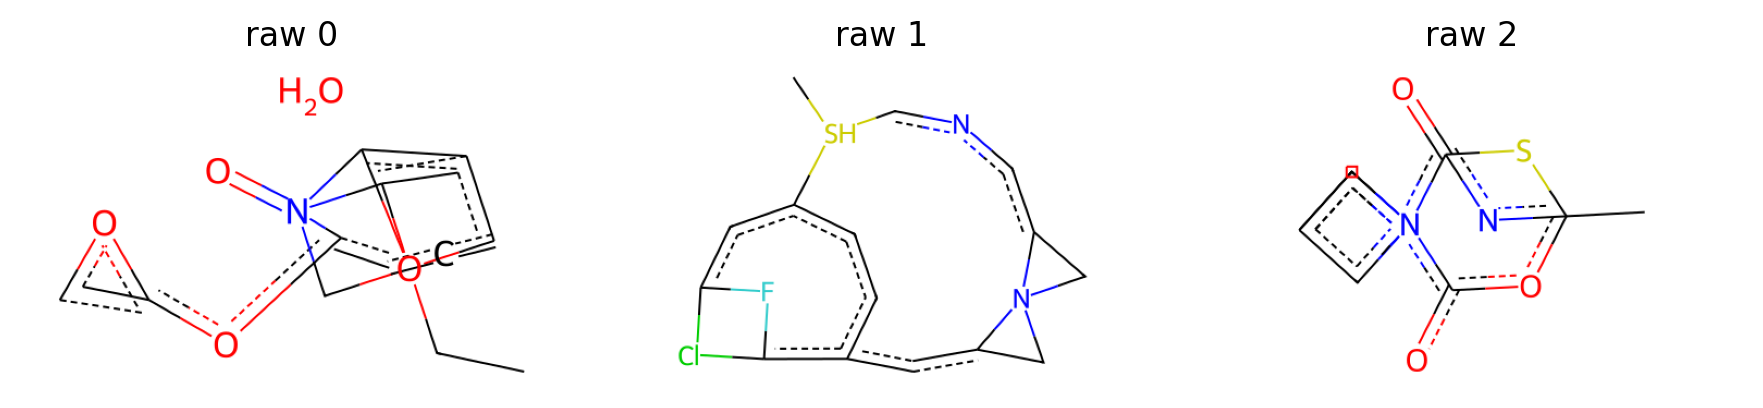

Non-streaming ZINC ilp samples


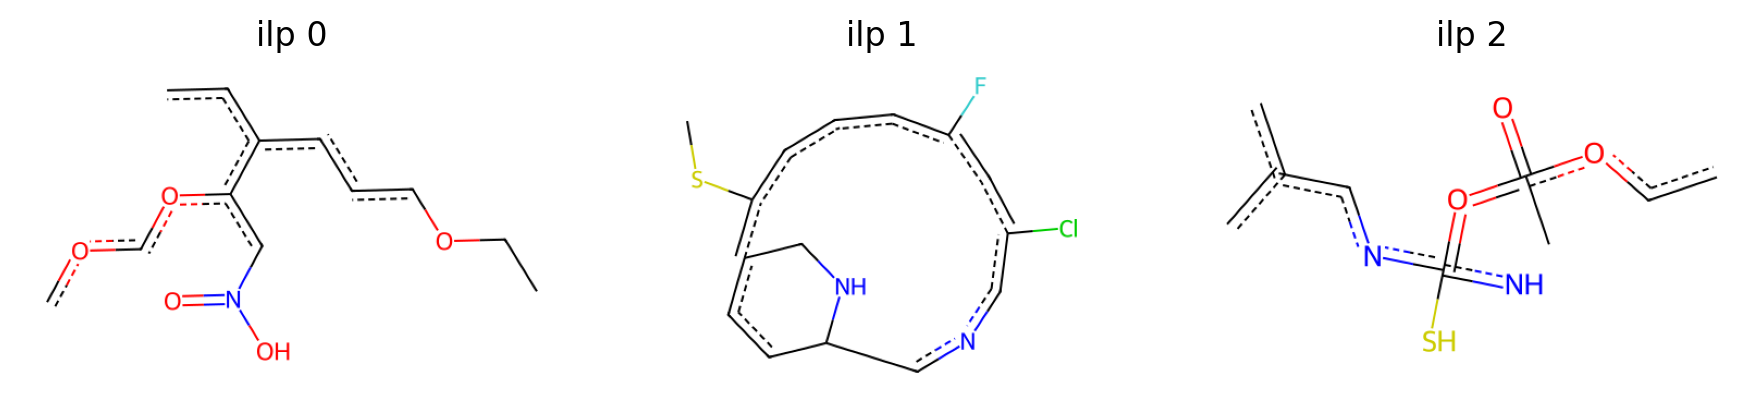

Non-streaming ZINC oracle ilp samples


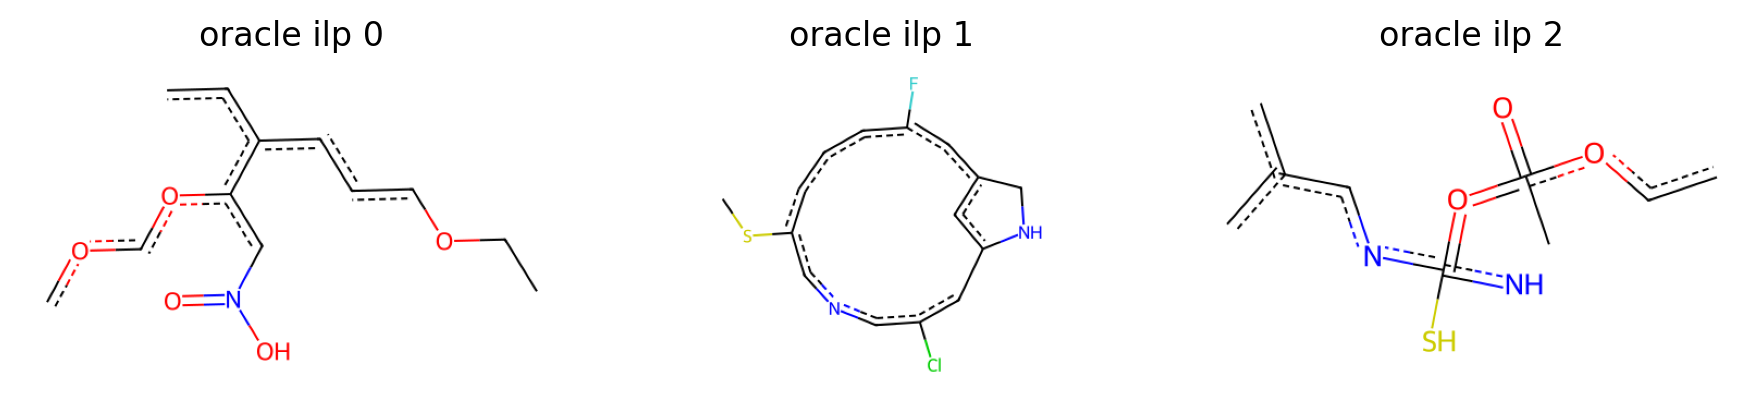

In [6]:
n_samples = 3
sample_variants = graph_generator.sample(n_samples, return_decode_stages=True)

for variant_key, title_prefix in (
    ('raw', 'raw'),
    ('ilp', 'ilp'),
    ('oracle', 'oracle ilp'),
):
    variant_samples = [graph for graph in sample_variants[variant_key] if graph is not None]
    if not variant_samples:
        print(f'No {title_prefix} samples to display.')
        continue
    show_molecules(
        variant_samples,
        n=len(variant_samples),
        title=f'Non-streaming ZINC {title_prefix} samples',
        legends=[f'{title_prefix} {idx}' for idx in range(len(variant_samples))],
        n_graphs_per_line=n_samples,
    )


Feasibility attempt  1/20 | generated=   8 | feasible_candidates= 1 | feasible_rate= 12.5% | attempt_time=16m 54.2s | eta=    0.0s
Feasibility filtering summary: generated=8, feasible_candidates=1, feasible_rate=12.5%, fulfilled_slots=1/1.
Feasibility attempt  1/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=4m 23.0s | eta=1h 23m 16.7s
Feasibility attempt  2/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=7m 12.9s | eta=1h 44m 23.0s
Feasibility attempt  3/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=8m 51.8s | eta=1h 55m 56.9s
Oracle-guided adjacency solve failed with 19 active cuts at iteration 7/16; retrying with fewer cuts.
Feasibility attempt  4/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=6m 55.9s | eta=1h 49m 34.5s
Feasibility attempt  5/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=9m 08.7s | eta=1

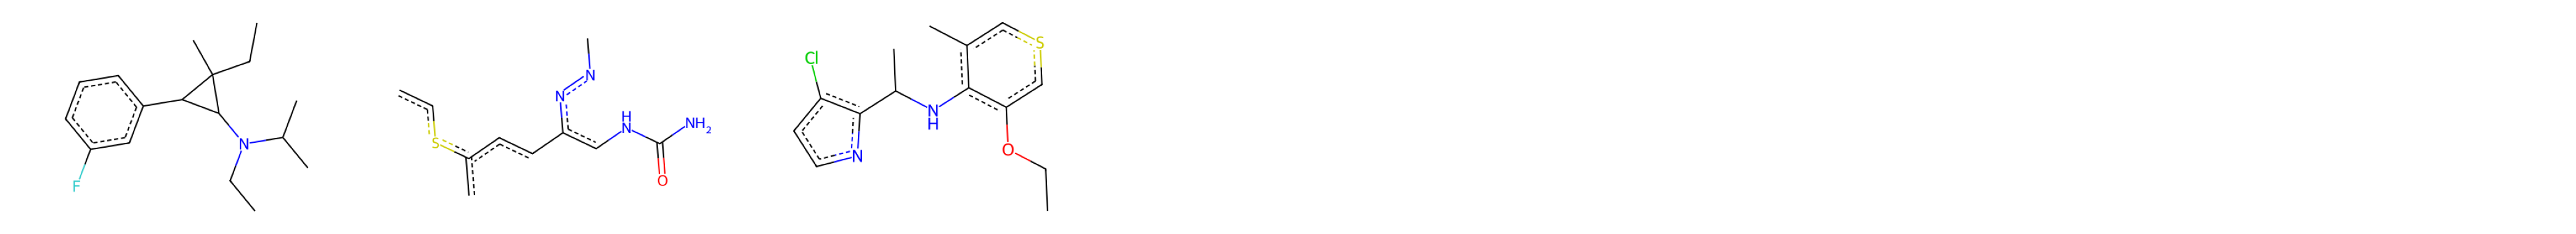

In [7]:
if graph_generator.feasibility_estimator is None:
    raise RuntimeError('Feasibility estimator is unavailable in this environment.')

filtered_samples = graph_generator.sample(
    n_samples=n_samples,
    apply_feasibility_filtering=True,
)
show_molecules(filtered_samples, n=n_samples, title='Non-streaming ZINC samples with feasibility filtering')
